# table of content

[1.curve text](#curve-text)

[2.align crop text](#align-crop-text)

[3.vertical dilate text](#vertical-dilate-text)

[4.check accuracy](#check-accuracy)

[5.check roi](#check-roi)

[6.v cut](#v-cut)

[7.histogram](#histogram)

[8.text discriminator](#text-discriminator)

[9.add image](#add-image)

# curve text

https://stackoverflow.com/questions/61725926/how-to-convert-curves-in-images-to-lines-in-python

In [141]:
from skimage import io, measure, morphology
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

(213, 245)


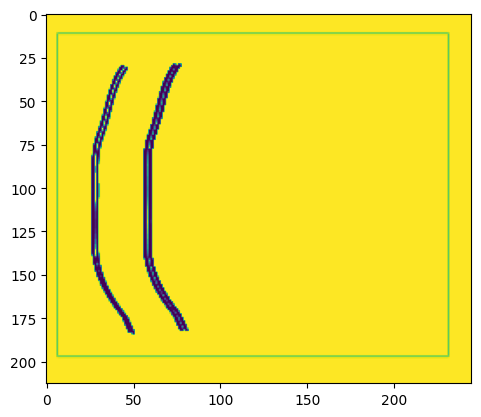

In [45]:
# read the image
image = io.imread('snippets/curve.png', as_gray=True)
print(image.shape)
plt.imshow(image)

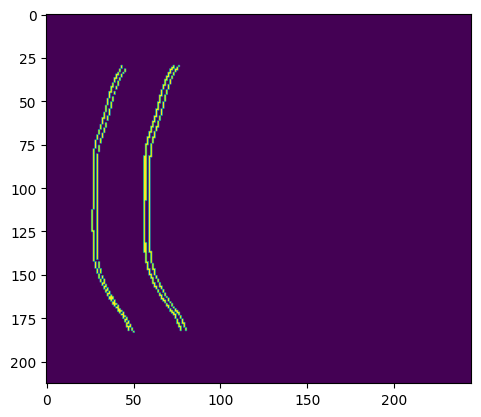

In [46]:
# need a binary mask of features
mask = image == image.min()
plt.imshow(mask)

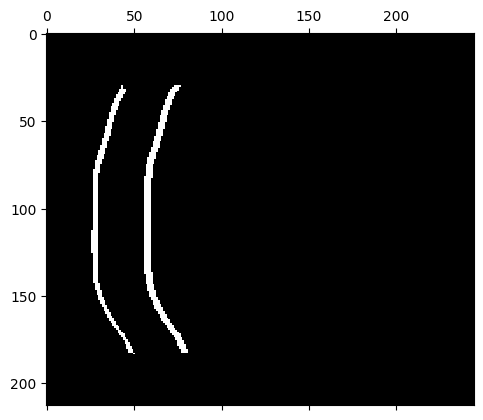

In [47]:
# close holes in features
mask = morphology.binary_closing(mask, morphology.square(3))
plt.matshow(mask, cmap='gray')

In [48]:
# need to get the coordinates of each feature
rp = measure.regionprops(measure.label(mask))

In [49]:
# going to fit a parabola to the features
def parabola(x,x0,A,y0):
    return A*(x-x0)**2+y0

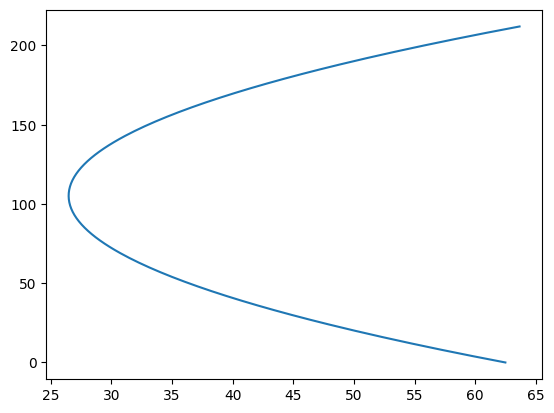

In [50]:
# get coords of one of the features
coords = rp[0].coords
# do parabola fit
pop, pcov = curve_fit(parabola, coords[:,0], coords[:,1])
# generate fit
fit = parabola(np.arange(mask.shape[0]), *pop)
# plot fit
plt.plot(fit, np.arange(mask.shape[0])) # invert axes

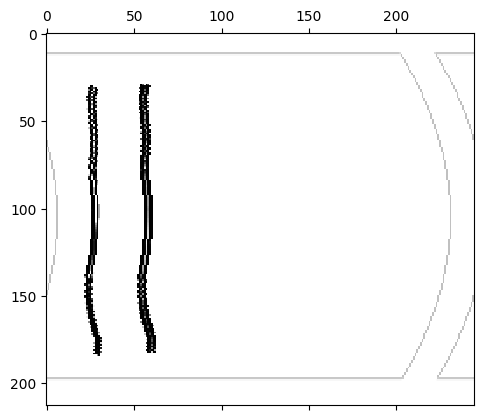

In [51]:
# generate new image to shift
out = np.empty_like(image)
#shift each row individually and add to out array
for i, row in enumerate(image):
    out[i] = np.roll(row,-int(round(fit[i]-pop[-1])))
plt.matshow(out,cmap='gray')

**Text image**

In [52]:
import cv2
from paddleocr import PaddleOCR

In [53]:
from skimage import io, measure, morphology
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np

In [54]:
ocr = PaddleOCR(det_model_dir='models/ch_PP-OCRv3_det_infer',
                rec_model_dir='models/ch_PP-OCRv3_rec_infer',
                cls_model_dir='models/ch_ppocr_mobile_v2.0_cls_infer', 
                use_angle_cls=True)

[2023/01/30 19:02:06] ppocr DEBUG: Namespace(alpha=1.0, benchmark=False, beta=1.0, cls_batch_num=6, cls_image_shape='3, 48, 192', cls_model_dir='models/ch_ppocr_mobile_v2.0_cls_infer', cls_thresh=0.9, cpu_threads=10, crop_res_save_dir='./output', det=True, det_algorithm='DB', det_box_type='quad', det_db_box_thresh=0.6, det_db_score_mode='fast', det_db_thresh=0.3, det_db_unclip_ratio=1.5, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_east_score_thresh=0.8, det_limit_side_len=960, det_limit_type='max', det_model_dir='models/ch_PP-OCRv3_det_infer', det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, det_pse_thresh=0, det_sast_nms_thresh=0.2, det_sast_score_thresh=0.5, draw_img_save_dir='./inference_results', drop_score=0.5, e2e_algorithm='PGNet', e2e_char_dict_path='./ppocr/utils/ic15_dict.txt', e2e_limit_side_len=768, e2e_limit_type='max', e2e_model_dir=None, e2e_pgnet_mode='fast', e2e_pgnet_score_thresh=0.5, e2e_pgnet_valid_set='totaltext', enable_mkldnn=False, four

(453, 223)


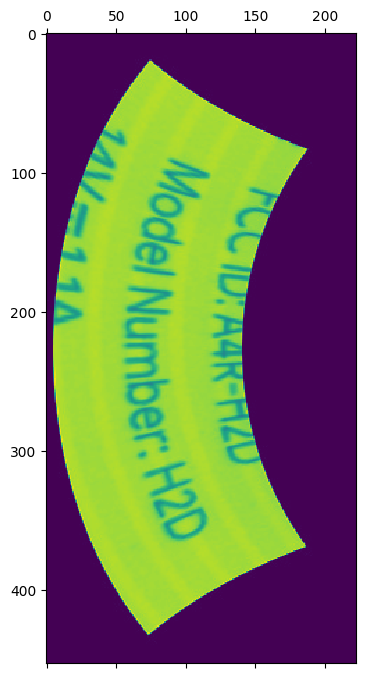

In [56]:
img = io.imread('snippets/curve2.jpg',as_gray=True)
print(img.shape)
plt.matshow(img)

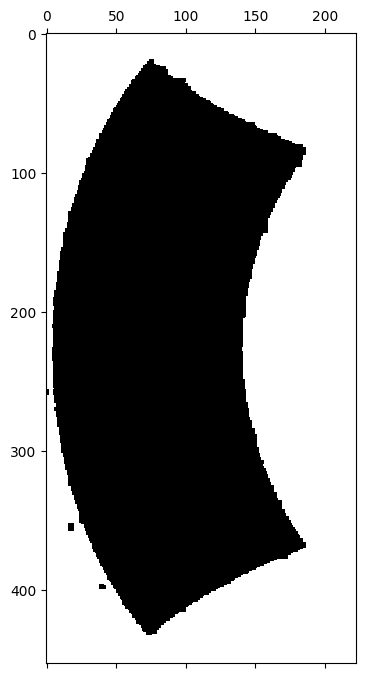

In [57]:
# need a binary mask of features
mask = img == img.min()
# close holes in features
mask = morphology.binary_closing(mask,morphology.square(3))
plt.matshow(mask,cmap='gray')

In [58]:
# need to get coordinates of each feature
rp = measure.regionprops(measure.label(mask))
rp

In [59]:
# going to fit parabola to the features
def parabola(x,x0,A,y0):
    return A*(x-x0)**2 + y0

In [60]:
# get coords of one of the features
coords = rp[0].coords
coords.shape

(50523, 2)

In [61]:
# do parabola fit
pop,pcov = curve_fit(parabola,coords[:,0],coords[:,1])
print("pop\n",pop)
print("pcov\n",pcov)

pop
 [ 2.26449310e+02 -1.29657097e-03  1.65541888e+02]
pcov
 [[ 6.18371338e-01  9.55681882e-08 -2.08380590e-03]
 [ 9.55681882e-08  3.33432770e-10 -7.79322355e-06]
 [-2.08380590e-03 -7.79322355e-06  2.79332229e-01]]


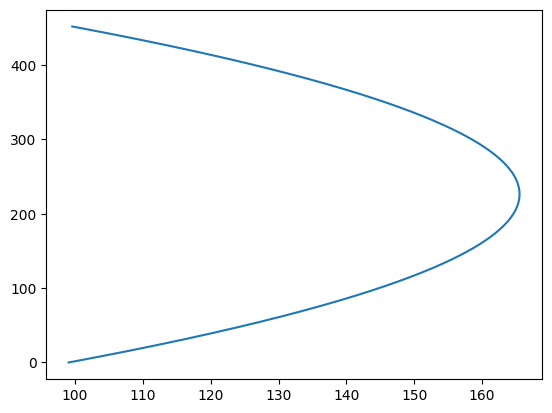

In [62]:
# generate fit
fit =  parabola(np.arange(mask.shape[0]),*pop)
#plot fit
plt.plot(fit,np.arange(mask.shape[0])) # invert axes

In [63]:
#generate new image to shift
out = np.empty_like(img)

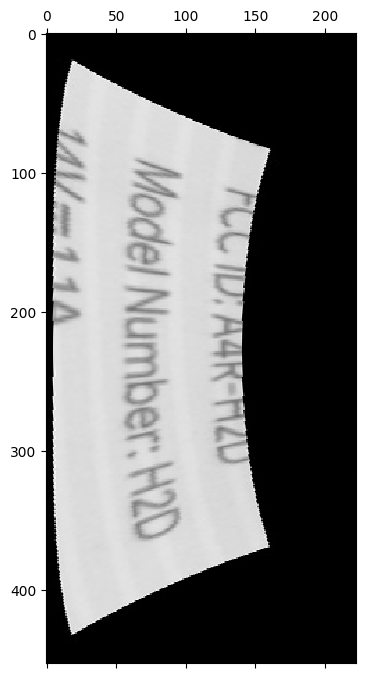

In [64]:
# shift each row individually and add to out array
for i,row in enumerate(img):
    out[i] = np.roll(row,+int(round(fit[i] - pop[-1])))
    
plt.matshow(out,cmap='gray')

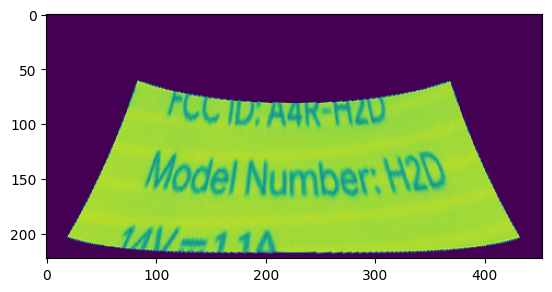

In [65]:
out = cv2.rotate(out,cv2.ROTATE_90_CLOCKWISE)
out = cv2.rotate(out,cv2.ROTATE_90_CLOCKWISE)
out = cv2.rotate(out,cv2.ROTATE_90_CLOCKWISE)
out = out * 255
plt.imshow(out)

[[('Model Number: H2D', 0.8476500511169434)]]

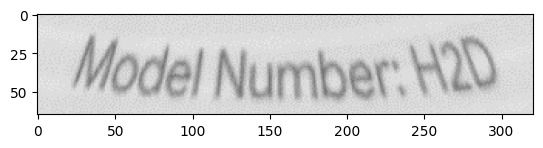

In [66]:
img = cv2.imread('snippets/crop.jpg')
plt.imshow(img)
ocr.ocr(img,det=False,rec=True,cls=True)

(65, 321)


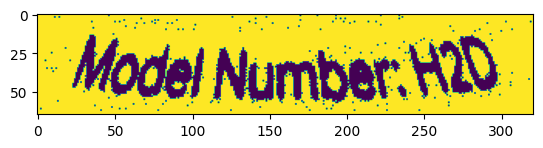

In [67]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
mask = gray > 200
mask = mask *255
print(mask.shape)
plt.imshow(mask)

[[('Model Number:H2D', 0.9033052325248718)]]

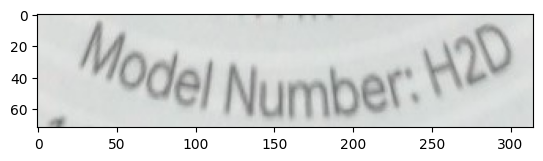

In [68]:
img = cv2.imread('snippets/crop2.jpg')
plt.imshow(img)
ocr.ocr(img,det=False,rec=True,cls=True)

# align crop text

https://stackoverflow.com/questions/42879716/straightening-contoured-rectangles-in-opencv-python

In [205]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

(386, 448, 3)


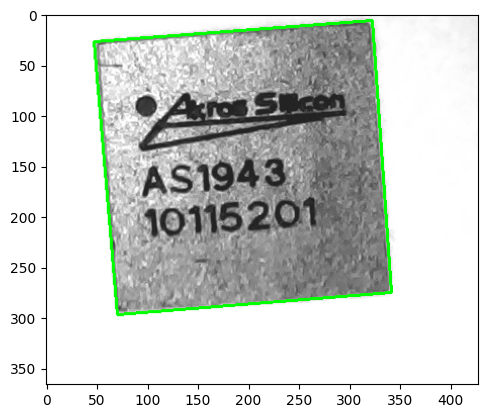

In [206]:
#get the minimum bounding box
img = cv2.imread('chip3.png',cv2.IMREAD_COLOR)
print(img.shape)
img = img[10:-10,10:-10]
plt.imshow(img)

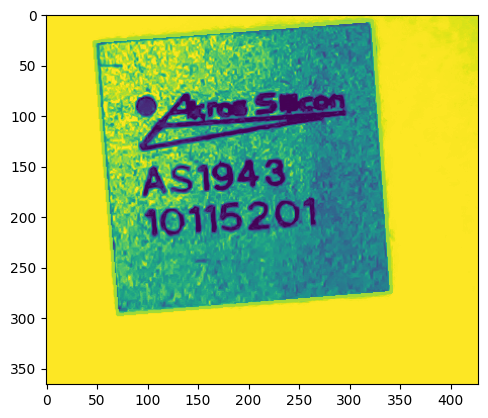

In [207]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2LAB)[...,0]
plt.imshow(gray)

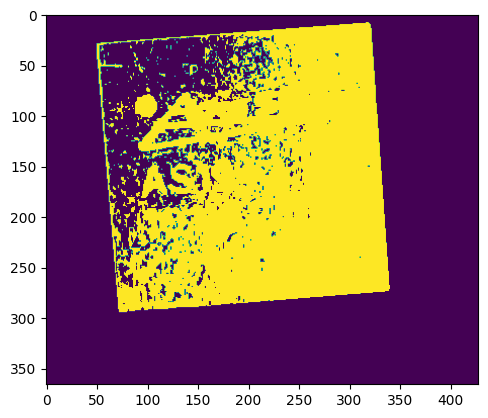

In [208]:
ret,thresh = cv2.threshold(gray,20,255,cv2.THRESH_BINARY|cv2.THRESH_OTSU)
mask = 255 -thresh
plt.imshow(mask)

In [209]:
contours,_ = cv2.findContours(mask,cv2.RETR_TREE,cv2.CHAIN_APPROX_NONE)
print(len(contours))

577


In [210]:
maxArea = 0
best_contour = None
for contour in contours:
    area = cv2.contourArea(contour)
    if area > maxArea:
        maxArea = area
        best_contour = contour

rect = cv2.minAreaRect(best_contour)
box = cv2.boxPoints(rect)
box = np.int0(box)

In [211]:
#crop image inside bounding box
scale = 1  # cropping margin, 1 == no margin
W = rect[1][0]
H = rect[1][1]

Xs = [i[0] for i in box]
Ys = [i[1] for i in box]
x1 = min(Xs)
x2 = max(Xs)
y1 = min(Ys)
y2 = max(Ys)

angle = rect[2]
rotated = False
if angle < -45:
    angle += 90
    rotated = True

center = (int((x1+x2)/2), int((y1+y2)/2))
size = (int(scale*(x2-x1)), int(scale*(y2-y1)))

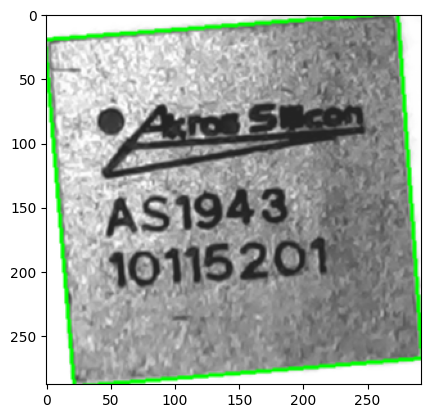

In [212]:
M = cv2.getRotationMatrix2D((size[0]/2, size[1]/2), angle, 1.0)

cropped = cv2.getRectSubPix(img, size, center)
plt.imshow(cropped)

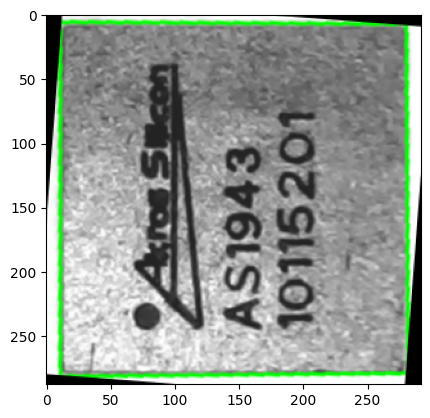

In [213]:
cropped = cv2.warpAffine(cropped, M, size)

plt.imshow(cropped)

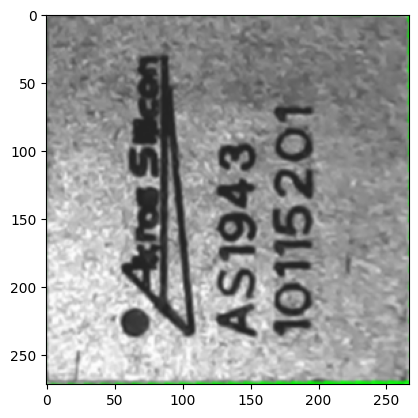

In [214]:
croppedW = W if not rotated else H
croppedH = H if not rotated else W

image = cv2.getRectSubPix(cropped, (int(croppedW*scale), int(croppedH*scale)), (size[0]/2, size[1]/2))
plt.imshow(image)

# vertical dilate text

https://stackoverflow.com/questions/59050090/using-dilation-in-only-one-direction

In [219]:
import cv2
import matplotlib.pyplot as plt 

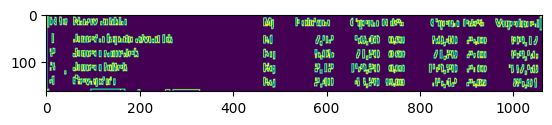

In [241]:
img = cv2.imread('snippets/img.jpg',0)
h,w = img.shape
plt.imshow(img)

In [242]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT,ksize= (1,2*h))
print(kernel.shape)

(328, 1)


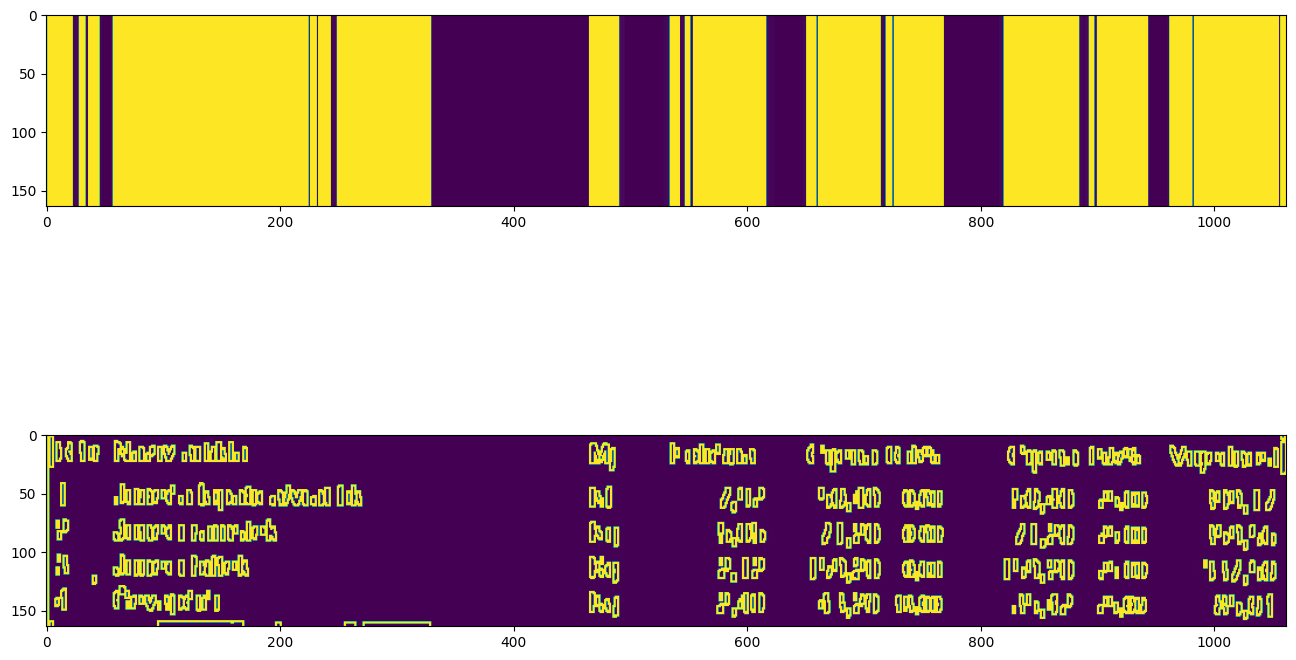

In [243]:
dilated = cv2.dilate(img,kernel)

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16,10))

axes[1].imshow(img)
axes[0].imshow(dilated)

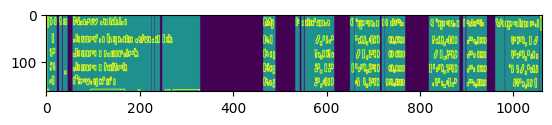

In [244]:
blended = (img.astype('float')+dilated.astype('float'))/2
plt.imshow(blended)

# crop text

In [246]:
import cv2
import os
import numpy as np
import random
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR

In [247]:
ocr = PaddleOCR(det_model_dir='models/ch_PP-OCRv3_det_infer',
                rec_model_dir='models/ch_PP-OCRv3_rec_infer',
                cls_model_dir='models/ch_ppocr_mobile_v2.0_cls_infer', 
                use_angle_cls=True)

[2023/01/30 23:17:06] ppocr DEBUG: Namespace(alpha=1.0, benchmark=False, beta=1.0, cls_batch_num=6, cls_image_shape='3, 48, 192', cls_model_dir='models/ch_ppocr_mobile_v2.0_cls_infer', cls_thresh=0.9, cpu_threads=10, crop_res_save_dir='./output', det=True, det_algorithm='DB', det_box_type='quad', det_db_box_thresh=0.6, det_db_score_mode='fast', det_db_thresh=0.3, det_db_unclip_ratio=1.5, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_east_score_thresh=0.8, det_limit_side_len=960, det_limit_type='max', det_model_dir='models/ch_PP-OCRv3_det_infer', det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, det_pse_thresh=0, det_sast_nms_thresh=0.2, det_sast_score_thresh=0.5, draw_img_save_dir='./inference_results', drop_score=0.5, e2e_algorithm='PGNet', e2e_char_dict_path='./ppocr/utils/ic15_dict.txt', e2e_limit_side_len=768, e2e_limit_type='max', e2e_model_dir=None, e2e_pgnet_mode='fast', e2e_pgnet_score_thresh=0.5, e2e_pgnet_valid_set='totaltext', enable_mkldnn=False, four

# add image

In [245]:
import cv2
import os
import numpy as np
import random
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR

In [70]:
ocr = PaddleOCR(det_model_dir='models/ch_PP-OCRv3_det_infer',
                rec_model_dir='models/ch_PP-OCRv3_rec_infer',
                cls_model_dir='models/ch_ppocr_mobile_v2.0_cls_infer', 
                use_angle_cls=True)

[2023/01/30 19:04:21] ppocr DEBUG: Namespace(alpha=1.0, benchmark=False, beta=1.0, cls_batch_num=6, cls_image_shape='3, 48, 192', cls_model_dir='models/ch_ppocr_mobile_v2.0_cls_infer', cls_thresh=0.9, cpu_threads=10, crop_res_save_dir='./output', det=True, det_algorithm='DB', det_box_type='quad', det_db_box_thresh=0.6, det_db_score_mode='fast', det_db_thresh=0.3, det_db_unclip_ratio=1.5, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_east_score_thresh=0.8, det_limit_side_len=960, det_limit_type='max', det_model_dir='models/ch_PP-OCRv3_det_infer', det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, det_pse_thresh=0, det_sast_nms_thresh=0.2, det_sast_score_thresh=0.5, draw_img_save_dir='./inference_results', drop_score=0.5, e2e_algorithm='PGNet', e2e_char_dict_path='./ppocr/utils/ic15_dict.txt', e2e_limit_side_len=768, e2e_limit_type='max', e2e_model_dir=None, e2e_pgnet_mode='fast', e2e_pgnet_score_thresh=0.5, e2e_pgnet_valid_set='totaltext', enable_mkldnn=False, four

img:  crop_120.jpg
mean:  219
Text:  Model: GXCA6 Coef:  0.7669646739959717


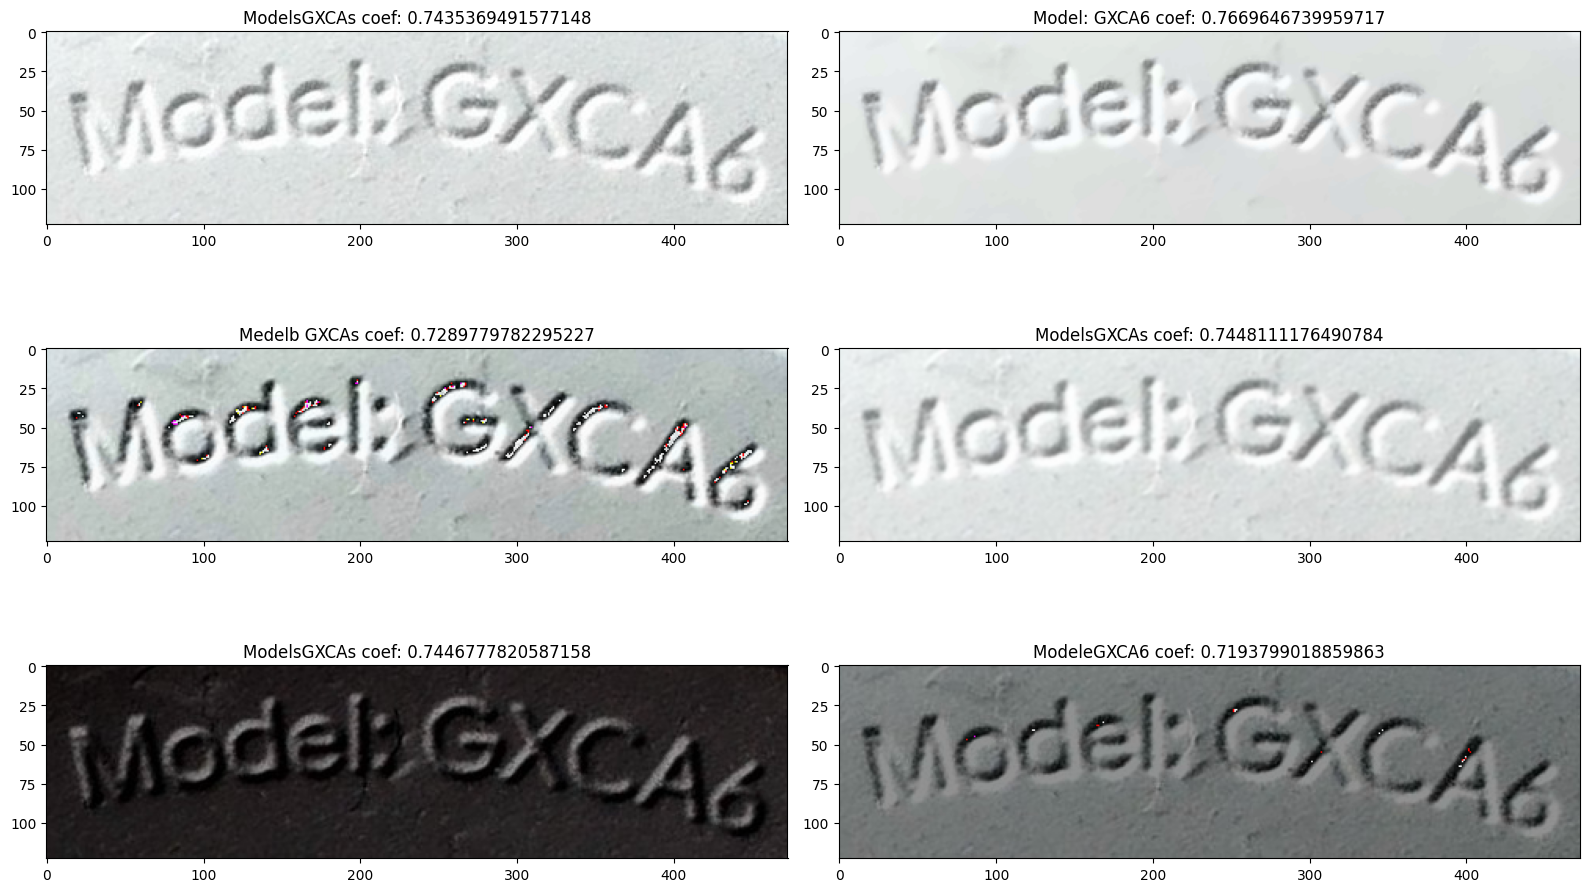

In [71]:
path = 'crops'

imgs = os.listdir(path)
img = random.choice(imgs)
print('img: ',img)

# original
img = cv2.imread(os.path.join(path,img))

# denoise
img2 = cv2.fastNlMeansDenoisingColored(img,None,3,3,7,21)

# denoise + orignal
img3 = img + img2

# blur
img4 = cv2.GaussianBlur(img,(3,3),0)

# reverse
img5 = 255 - img

# normalize
img6 = img - int(0.5*np.mean(img))

mean = np.mean(img).astype(np.uint8)
print('mean: ',mean)

imgs =[img,img2,img3,img4,img5,img6]
coef = []
text = []

for i in range(len(imgs)):
    im = imgs[i]
    t,c = ocr.ocr(im,det=False,rec=True,cls=True)[0][0]
    text.append(t)
    coef.append(c)

i = np.argmax(coef)
t = text[i]
c = coef[i]

print("Text: ",t,"Coef: ",c)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16,10))

axes[0][0].imshow(img)
axes[0][0].set_title(f"{text[0]} coef: {coef[0]}")

axes[0][1].imshow(img2)
axes[0][1].set_title(f"{text[1]} coef: {coef[1]}")

axes[1][0].imshow(img3)
axes[1][0].set_title(f"{text[2]} coef: {coef[2]}")

axes[1][1].imshow(img4)
axes[1][1].set_title(f"{text[3]} coef: {coef[3]}")

axes[2][0].imshow(img5)
axes[2][0].set_title(f"{text[4]} coef: {coef[4]}")

axes[2][1].imshow(img6)
axes[2][1].set_title(f"{text[5]} coef: {coef[5]}")

plt.tight_layout()

# references

[using-dilation-in-only-one-direction](https://stackoverflow.com/questions/59050090/using-dilation-in-only-one-direction)

[straightening-contoured-rectangles](https://stackoverflow.com/questions/42879716/straightening-contoured-rectangles-in-opencv-python)

[How to convert curves in images to lines in Python?](https://stackoverflow.com/questions/61725926/how-to-convert-curves-in-images-to-lines-in-python)

[paddleocr](https://github.com/PaddlePaddle/PaddleOCR/blob/release/2.6/paddleocr.py)

[OPENCV: 'FAST' LIKE CORNER DETECTION WITH SCANNING WINDOW](http://dsynflo.blogspot.com/2014/07/opencv-fast-like-corner-detection-with.html)

[006 Morphological transformations with OpenCV in Python](https://datahacker.rs/006-morphological-transformations-with-opencv-in-python/)

[Morphological Transformations](https://docs.opencv.org/3.4/d4/d76/tutorial_js_morphological_ops.html)

[Image Denoising](https://docs.opencv.org/3.4/d5/d69/tutorial_py_non_local_means.html)

[Basics of Brute-Force Matcher](https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html)